In [17]:
 # 1. Import Dependencies
import pandas as pd
import numpy as np
from sklearn import svm
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import random


In [18]:
# 2. Data Loading and Preprocessing
df = pd.read_csv("extracted_columns.csv")

X = df[['PSS-1', 'PSS-2', 'PSS-3', 'PSS-4', 'PSS-5', 'PSS-6', 'PSS-7', 
        'PSS-8', 'PSS-9', 'PSS-10', 'PSS-11', 'PSS-12', 'PSS-13', 'PSS-14']]
df['PSS_total'] = X.sum(axis=1)
y = df['PSS_total']


In [19]:
# 3. SVR Implementation
param_bounds = {
    'C': [0.1, 1000],
    'epsilon': [0.01, 1.0],
    'kernel': ['linear', 'rbf']
}

def create_individual():
    return {
        'C': random.uniform(param_bounds['C'][0], param_bounds['C'][1]),
        'epsilon': random.uniform(param_bounds['epsilon'][0], param_bounds['epsilon'][1]),
        'kernel': random.choice(param_bounds['kernel'])
    }

def fitness(individual, X_train, y_train, X_val, y_val):
    model = make_pipeline(StandardScaler(), SVR(C=individual['C'], 
                                              epsilon=individual['epsilon'], 
                                              kernel=individual['kernel']))
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return -np.sqrt(mean_squared_error(y_val, preds))

def select(population, k=3):
    selected = random.sample(population, k)
    selected = sorted(selected, key=lambda x: x['fitness'], reverse=True)
    return selected[0]

def crossover(parent1, parent2):
    child = {}
    for key in parent1.keys():
        child[key] = parent1[key] if random.random() > 0.5 else parent2[key]
    return child

def mutate(individual, mutation_rate=0.1):
    if random.random() < mutation_rate:
        individual['C'] += random.uniform(-10, 10)
        individual['C'] = np.clip(individual['C'], param_bounds['C'][0], param_bounds['C'][1])
    if random.random() < mutation_rate:
        individual['epsilon'] += random.uniform(-0.05, 0.05)
        individual['epsilon'] = np.clip(individual['epsilon'], param_bounds['epsilon'][0], param_bounds['epsilon'][1])
    if random.random() < mutation_rate:
        individual['kernel'] = random.choice(param_bounds['kernel'])
    return individual

def genetic_algorithm(X, y, generations=10, population_size=20):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    population = [create_individual() for _ in range(population_size)]
    
    for individual in population:
        individual['fitness'] = fitness(individual, X_train, y_train, X_val, y_val)

    for gen in range(generations):
        new_population = []
        while len(new_population) < population_size:
            parent1 = select(population)
            parent2 = select(population)
            child = crossover(parent1, parent2)
            child = mutate(child)
            child['fitness'] = fitness(child, X_train, y_train, X_val, y_val)
            new_population.append(child)
        population = new_population
        best = max(population, key=lambda x: x['fitness'])
        print(f"Generation {gen+1}, Best RMSE: {-best['fitness']:.4f}, Params: {best}")

    best_individual = max(population, key=lambda x: x['fitness'])
    return best_individual


In [20]:
# 5. Model Evaluation
def evaluate_and_plot(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} RMSE:", rmse)
    print(f"{model_name} MAE:", mae)
    print(f"{model_name} R^2:", r2)
    
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.show()


Generation 1, Best RMSE: 0.0626, Params: {'C': 166.79127798831817, 'epsilon': 0.14437493299067838, 'kernel': 'linear', 'fitness': np.float64(-0.06262432720831378)}
Generation 2, Best RMSE: 0.0623, Params: {'C': 166.79127798831817, 'epsilon': np.float64(0.14370662418178468), 'kernel': 'linear', 'fitness': np.float64(-0.062346569529137724)}
Generation 3, Best RMSE: 0.0488, Params: {'C': 166.79127798831817, 'epsilon': np.float64(0.11231927273181505), 'kernel': 'linear', 'fitness': np.float64(-0.048787560718746584)}
Generation 4, Best RMSE: 0.0488, Params: {'C': 166.79127798831817, 'epsilon': np.float64(0.11231927273181505), 'kernel': 'linear', 'fitness': np.float64(-0.048787560718746584)}
Generation 5, Best RMSE: 0.0488, Params: {'C': 166.79127798831817, 'epsilon': np.float64(0.11231927273181505), 'kernel': 'linear', 'fitness': np.float64(-0.048787560718746584)}
Generation 6, Best RMSE: 0.0479, Params: {'C': 166.79127798831817, 'epsilon': np.float64(0.11026979597456807), 'kernel': 'linear

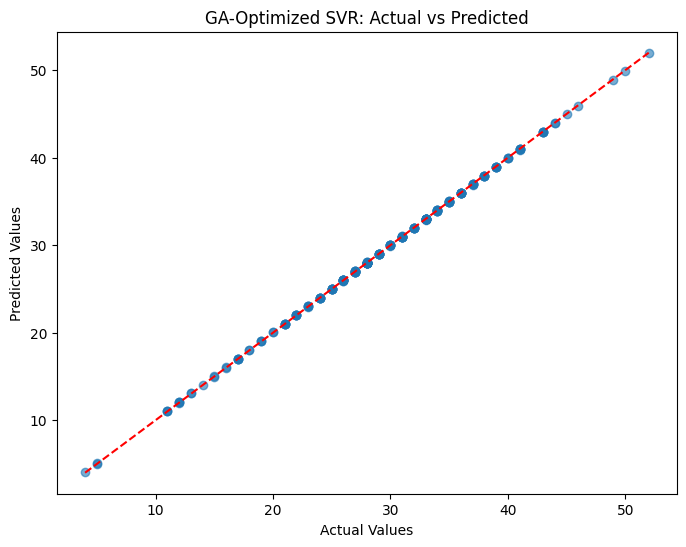

In [21]:
# SVR Expirement
best_params_svr = genetic_algorithm(X, y)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
optimized_svr = make_pipeline(
    StandardScaler(),
    SVR(C=best_params_svr['C'], epsilon=best_params_svr['epsilon'], kernel=best_params_svr['kernel'])
)
optimized_svr.fit(X_train, y_train)
y_pred_svr = optimized_svr.predict(X_val)
evaluate_and_plot('GA-Optimized SVR', y_val, y_pred_svr)

